In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Bollinger Band Mean Reversion — Signal Research

**Instruments:** SPY, QQQ, IWM (daily bars)
**Signal:** Long entry when close ≤ lower band (N-day mean − kσ).
**Entry:** Next day's open (avoids lookahead on close-triggered signal).
**Exit:** Close of the day that hits upper band (N-day mean + kσ), subject to minimum hold period.
**Direction:** Long-only.

**This notebook:**
1. Defines the signal engine
2. Grid search → optimal signal parameters (BB_PERIOD × BB_STD × MIN_HOLD_DAYS)
3. Generates trades with best params
4. Significance tests (gross & net)
5. Simple equity curve (gross vs net)
6. Overlap analysis — are SPY/QQQ/IWM sleeves independent?
7. Saves standardized trades for PM

**Sizing & implementation comparison** → see `Bollinger_Band_Implementation.ipynb`

**Parameter selection:** BB period and std dev are grid-searched. Default 30d/2σ
is close to Bollinger's original 20d/2σ standard (Bollinger on Bollinger Bands, 2001).
Min hold of 30 days is a practical constraint to separate from short-term portfolio.

**Academic backing:** Mean reversion in equity indexes is well-documented.
The strategy captures the short-horizon overreaction premium — buying oversold
conditions (lower band touch) and selling at fair value (upper band).
Validated via Kakushadze '151 Trading Strategies' screen (SSRN 3247865).

## 1. Setup

In [14]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.fees import calculate_fees, calculate_fees_pct
from _shared.implementations import build_daily_equity, build_multi_sleeve_equity
from _shared.significance import full_significance_report, print_significance_report

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [15]:
# =============================================================================
# CONFIGURATION
# =============================================================================

SYMBOLS    = ["SPY", "QQQ", "IWM"]
START_DATE = "2016-01-01"
END_DATE   = "2026-04-01"

STARTING_CAPITAL = 100_000
LEVERAGE         = 1           # Always 1 — leverage is a PM decision
STRATEGY_NAME    = "Bollinger Band"
SAVE_NAME        = "bollinger_band"
BET_SIZE         = 0.85        # For simple equity curve visualization

## 2. Data Fetching

In [16]:
data_dict = fetch_historical_data(
    SYMBOLS, TimeFrame(1, TimeFrameUnit.Day), START_DATE, END_DATE)

all_data = {}
for sym in SYMBOLS:
    d = data_dict[sym].copy()
    if d.index.tz is None:
        d.index = d.index.tz_localize("UTC").tz_convert("US/Eastern")
    else:
        d.index = d.index.tz_convert("US/Eastern")
    d = d.reset_index()
    d["date"] = d["timestamp"].dt.date
    d = d.groupby("date").last().reset_index()
    d["date"] = pd.to_datetime(d["date"])
    d = d[["date", "open", "high", "low", "close", "volume"]].sort_values("date").reset_index(drop=True)
    all_data[sym] = d
    print(f"{sym}: {len(d):,} bars, {d['date'].iloc[0].date()} → {d['date'].iloc[-1].date()}")

Fetching SPY...
  2,575 bars
Fetching QQQ...
  2,575 bars
Fetching IWM...
  2,575 bars
SPY: 2,575 bars, 2016-01-04 → 2026-03-31
QQQ: 2,575 bars, 2016-01-04 → 2026-03-31
IWM: 2,575 bars, 2016-01-04 → 2026-03-31


## 3. Signal Engine

Generates raw trades — **no position sizing, no equity tracking.**
The `pct_return_gross` is the raw price move, independent of leverage or account size.

**Entry:** Next day's open after close ≤ lower band.
**Exit:** Close of the day that close ≥ upper band, subject to `min_hold_days`.
If the upper band is breached before `min_hold_days`, keep holding until both
conditions are met (close ≥ upper band AND days held ≥ min_hold_days).

In [17]:
def generate_signals(all_data, bb_period, bb_std, min_hold_days=0):
    """
    Generate raw Bollinger Band mean reversion trades — signal only, no sizing.

    Entry: next day's open after close ≤ lower band.
    Exit:  close of the day where close ≥ upper band AND days held ≥ min_hold_days.
           Falls back to end_of_data if never triggered.

    Returns DataFrame with standardized columns:
        entry_time, exit_time, direction, instrument, entry_price,
        exit_price, pct_return_gross, exit_reason, stop_price
    """
    trades = []

    for sym, df in all_data.items():
        df = df.copy()
        df["bb_mid"]   = df["close"].rolling(window=bb_period).mean()
        df["bb_stdev"] = df["close"].rolling(window=bb_period).std()
        df["bb_upper"] = df["bb_mid"] + bb_std * df["bb_stdev"]
        df["bb_lower"] = df["bb_mid"] - bb_std * df["bb_stdev"]
        df = df.dropna(subset=["bb_upper", "bb_lower"]).reset_index(drop=True)

        in_pos = False
        entry_price = entry_time = None

        for i in range(len(df)):
            row = df.iloc[i]

            if not in_pos:
                if row["close"] <= row["bb_lower"]:
                    # Signal triggered — entry at NEXT day's open
                    if i + 1 < len(df):
                        next_row = df.iloc[i + 1]
                        in_pos = True
                        entry_price = next_row["open"]
                        entry_time  = next_row["date"]
            else:
                days_held = (row["date"] - entry_time).days
                if row["close"] >= row["bb_upper"] and days_held >= min_hold_days:
                    exit_price = row["close"]
                    exit_time  = row["date"]
                    pct_return_gross = (exit_price - entry_price) / entry_price
                    trades.append({
                        "entry_time":       entry_time,
                        "exit_time":        exit_time,
                        "direction":        "long",
                        "instrument":       sym,
                        "entry_price":      round(entry_price, 4),
                        "exit_price":       round(exit_price, 4),
                        "pct_return_gross": round(pct_return_gross, 6),
                        "exit_reason":      "upper_band",
                        "stop_price":       np.nan,
                    })
                    in_pos = False

        # Close open position at end of data
        if in_pos:
            row = df.iloc[-1]
            exit_price = row["close"]
            exit_time  = row["date"]
            pct_return_gross = (exit_price - entry_price) / entry_price
            trades.append({
                "entry_time":       entry_time,
                "exit_time":        exit_time,
                "direction":        "long",
                "instrument":       sym,
                "entry_price":      round(entry_price, 4),
                "exit_price":       round(exit_price, 4),
                "pct_return_gross": round(pct_return_gross, 6),
                "exit_reason":      "end_of_data",
                "stop_price":       np.nan,
            })

    if not trades:
        return pd.DataFrame()
    out = pd.DataFrame(trades)
    out["entry_time"] = pd.to_datetime(out["entry_time"])
    out["exit_time"]  = pd.to_datetime(out["exit_time"])
    return out.sort_values("exit_time").reset_index(drop=True)

## 4. Parameter Grid Search

Find the best signal parameters before running the full evaluation.
Uses `calculate_fees_pct` for net Sharpe — no sizing needed.

`min_hold_days` is included in the grid to find the right hold constraint.

In [18]:
param_grid = {
    "bb_period":     [20, 30, 50],
    "bb_std":        [1.5, 2.0, 2.5],
    "min_hold_days": [0, 15, 30, 45],
}

param_keys = list(param_grid.keys())
all_combos = list(product(*param_grid.values()))
print(f"Total combinations: {len(all_combos)}")

grid_results = []
for combo in all_combos:
    params = dict(zip(param_keys, combo))
    try:
        res = generate_signals(all_data, **params)
        if res.empty or len(res) < 5:
            continue
        fee_pcts = res.apply(
            lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"]), axis=1)
        rets = res["pct_return_gross"] - fee_pcts
        n = len(rets)
        wins = (rets > 0).sum()
        total_ret = ((1 + rets).prod() - 1) * 100
        sharpe = rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0
        eq = STARTING_CAPITAL * (1 + rets).cumprod()
        max_dd = ((eq - eq.expanding().max()) / eq.expanding().max()).min() * 100
        pf = abs(rets[rets > 0].sum() / rets[rets < 0].sum()) if rets[rets < 0].sum() != 0 else np.inf
        avg_hold = (res["exit_time"] - res["entry_time"]).dt.days.mean()

        grid_results.append({
            **params,
            "Trades": n, "Win Rate": round(wins/n*100, 1),
            "Total Return": round(total_ret, 1),
            "Sharpe": round(sharpe, 2), "Max Drawdown": round(max_dd, 1),
            "Profit Factor": round(pf, 2),
            "Avg Hold": round(avg_hold, 1),
        })
    except Exception as e:
        print(f"Skipped {params}: {e}")

grid_df = pd.DataFrame(grid_results)
print(f"Completed: {len(grid_results)}")

# Correct Sharpe for actual holding period: sqrt(avg_hold/252) not sqrt(252)
grid_df["sharpe_corrected"] = grid_df.apply(
    lambda r: r["Sharpe"] * 1.0 / np.sqrt(max(r["Avg Hold"], 1))
              if r["Sharpe"] > 0 else r["Sharpe"], axis=1
).round(2)


Total combinations: 36
Completed: 36


In [19]:
if not grid_df.empty:
    display_cols = ["bb_period", "bb_std", "min_hold_days",
                    "sharpe_corrected", "Total Return", "Max Drawdown",
                    "Win Rate", "Profit Factor", "Trades", "Avg Hold"]
    available = [c for c in display_cols if c in grid_df.columns]
    top = grid_df.sort_values("sharpe_corrected", ascending=False).head(20)
    print("TOP PARAMETER COMBINATIONS (by corrected Sharpe):")
    print("=" * 140)
    print(top[available].to_string(index=False))
    print("\n(sharpe_corrected = annualized from daily, accounting for avg hold period)")

    best_row = grid_df.loc[grid_df["sharpe_corrected"].idxmax()]
    print(f"\nBest: bb_period={int(best_row['bb_period'])}, "
          f"bb_std={best_row['bb_std']}, min_hold={int(best_row['min_hold_days'])}d")

    print("\n\nMIN HOLD DAYS SENSITIVITY (at best bb_period/bb_std):")
    print("=" * 140)
    mask = ((grid_df["bb_period"] == best_row["bb_period"]) &
            (grid_df["bb_std"] == best_row["bb_std"]))
    print(grid_df[mask].sort_values("sharpe_corrected", ascending=False)[available].to_string(index=False))


TOP PARAMETER COMBINATIONS (by corrected Sharpe):
 bb_period  bb_std  min_hold_days  sharpe_corrected  Total Return  Max Drawdown  Win Rate  Profit Factor  Trades  Avg Hold
        50     1.5             15              1.75        1138.7         -18.4      81.4           7.34      59      57.2
        50     1.5             30              1.74        1431.9         -18.4      81.4           7.90      59      61.7
        50     1.5              0              1.74        1056.5         -18.4      81.4           7.17      59      56.9
        50     2.0             15              1.60        1830.4         -13.6      84.1          10.57      44      92.6
        50     2.0              0              1.59        1810.0         -13.6      84.1          10.54      44      92.5
        50     1.5             45              1.57        1550.4         -18.4      80.4           8.13      56      72.2
        50     2.0             45              1.55        1977.3          -8.5      82.9

In [20]:
# =============================================================================
# PARAMETER STABILITY ANALYSIS — trade-count weighted
# =============================================================================

print("=" * 80)
print("PARAMETER STABILITY ANALYSIS (trade-count weighted)")
print("=" * 80)
print("Score = avg rank, penalized for <50 trades.\n")

grid_df["rank"] = grid_df["sharpe_corrected"].rank(ascending=False)
grid_df["weighted_rank"] = grid_df["rank"] * (50 / grid_df["Trades"].clip(upper=50))

for param in ["bb_period", "bb_std", "min_hold_days"]:
    print(f"\n-- {param} --")
    summary = grid_df.groupby(param).agg(
        avg_wrank=("weighted_rank", "mean"),
        avg_sharpe_c=("sharpe_corrected", "mean"),
        min_sharpe_c=("sharpe_corrected", "min"),
        max_sharpe_c=("sharpe_corrected", "max"),
        avg_trades=("Trades", "mean"),
    ).round(2)
    summary = summary.sort_values("avg_wrank")
    print(summary.to_string())

print("\n" + "=" * 80)
print("RECOMMENDED STABLE PARAMETERS")
print("=" * 80)
stable = {}
for param in ["bb_period", "bb_std", "min_hold_days"]:
    best_val = grid_df.groupby(param)["weighted_rank"].mean().idxmin()
    avg_wr = grid_df.groupby(param)["weighted_rank"].mean().min()
    avg_tr = grid_df.groupby(param).apply(
        lambda g: g["Trades"].mean()).loc[best_val]
    stable[param] = best_val
    print(f"  {param}: {best_val} (avg weighted rank: {avg_wr:.1f}, avg trades: {avg_tr:.0f})")

stable_mask = True
for param, val in stable.items():
    stable_mask = stable_mask & (grid_df[param] == val)

stable_row = grid_df[stable_mask]
if not stable_row.empty:
    print(f"\n  Stable combo:")
    show = ["bb_period", "bb_std", "min_hold_days",
            "sharpe_corrected", "Total Return", "Max Drawdown", "Win Rate", "Trades", "Avg Hold"]
    avail = [c for c in show if c in stable_row.columns]
    print(f"  {stable_row[avail].to_string(index=False)}")
    print(f"\n  Grid-search best corrected Sharpe: {grid_df['sharpe_corrected'].max():.2f}")
    print(f"  Stable combo corrected Sharpe:     {stable_row['sharpe_corrected'].values[0]:.2f}")


PARAMETER STABILITY ANALYSIS (trade-count weighted)
Score = avg rank, penalized for <50 trades.


-- bb_period --
           avg_wrank  avg_sharpe_c  min_sharpe_c  max_sharpe_c  avg_trades
bb_period                                                                 
20             27.83          0.92          0.84          1.08       71.58
30             28.47          1.09          0.82          1.41       53.42
50             47.59          1.31          0.66          1.75       38.00

-- bb_std --
        avg_wrank  avg_sharpe_c  min_sharpe_c  max_sharpe_c  avg_trades
bb_std                                                                 
2.0         12.52          1.30          0.89          1.60       57.08
1.5         13.17          1.24          0.84          1.75       83.08
2.5         78.19          0.79          0.66          0.86       22.83

-- min_hold_days --
               avg_wrank  avg_sharpe_c  min_sharpe_c  max_sharpe_c  avg_trades
min_hold_days                        

### Set Parameters

Set `DEFAULT_PARAMS` based on grid search results (or keep manual choice).
Modify here if the grid search suggests a better combination.

In [21]:
# Set signal parameters — adjust based on grid search results above
DEFAULT_PARAMS = {
    "bb_period":     30,
    "bb_std":        2.0,
    "min_hold_days": 30,
}

print(f"Using params: {DEFAULT_PARAMS}")

Using params: {'bb_period': 30, 'bb_std': 2.0, 'min_hold_days': 30}


## 5. Signal Generation, Daily Equity & Significance Tests

Builds mark-to-market daily equity using `build_daily_equity` per sleeve.
Significance tests run on real daily returns — honest Sharpe and bootstrap CI.

In [22]:
raw_trades = generate_signals(all_data, **DEFAULT_PARAMS)
print(f"Total signal trades: {len(raw_trades)}")
print(f"By instrument: {dict(raw_trades['instrument'].value_counts())}")
print(f"Avg hold: {(raw_trades['exit_time'] - raw_trades['entry_time']).dt.days.mean():.1f} days")
print(f"Has stop_price: {raw_trades['stop_price'].notna().sum()} / {len(raw_trades)}")

raw_trades["fee_pct"] = raw_trades.apply(
    lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"]), axis=1)
raw_trades["pct_return_net"] = raw_trades["pct_return_gross"] - raw_trades["fee_pct"]

print(f"\nAvg fee: {raw_trades['fee_pct'].mean()*100:.4f}% per trade")
print(f"Avg gross return: {raw_trades['pct_return_gross'].mean()*100:.4f}%")
print(f"Avg net return: {raw_trades['pct_return_net'].mean()*100:.4f}%")

# ── Fetch daily prices for mark-to-market ──
_start = str(raw_trades["entry_time"].iloc[0].date())
_end = str(raw_trades["exit_time"].iloc[-1].date())
_daily_data = fetch_historical_data(SYMBOLS, TimeFrame(1, TimeFrameUnit.Day), _start, _end)

_daily_prices = {}
for sym in SYMBOLS:
    _d = _daily_data[sym].reset_index()
    _d["date"] = pd.to_datetime(_d["timestamp"]).dt.tz_localize(None).dt.normalize()
    _daily_prices[sym] = _d.set_index("date")["close"]

# ── Build mark-to-market daily equity per sleeve, then combine ──
sleeve_alloc = 1.0 / len(SYMBOLS)
sleeve_capital = STARTING_CAPITAL * sleeve_alloc
sleeve_daily = {}

for sym in SYMBOLS:
    t_sym = raw_trades[raw_trades["instrument"] == sym].reset_index(drop=True)
    if t_sym.empty:
        sleeve_daily[sym] = pd.Series(sleeve_capital, index=_daily_prices[sym].index)
        continue
    # Simple bet sizing to get shares
    eq = sleeve_capital
    eq_curve = [sleeve_capital]
    shares_list = []
    for _, t in t_sym.iterrows():
        if eq <= 0:
            shares_list.append(0)
            eq_curve.append(eq)
            continue
        s = int(eq * BET_SIZE / t["entry_price"])
        shares_list.append(s)
        pnl = s * (t["exit_price"] - t["entry_price"])
        fees = calculate_fees(s, t["entry_price"], t["exit_price"], t["direction"])
        eq += pnl - fees
        eq_curve.append(eq)
    t_sym_shares = t_sym.copy()
    t_sym_shares["shares"] = shares_list
    sleeve_daily[sym] = build_daily_equity(
        t_sym_shares, eq_curve, sleeve_capital, daily_prices=_daily_prices[sym])

daily_eq = build_multi_sleeve_equity(sleeve_daily, STARTING_CAPITAL)
daily_returns = daily_eq.pct_change().dropna()
real_sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252) if daily_returns.std() > 0 else 0
print(f"\nMark-to-market daily Sharpe: {real_sharpe:.2f}")

# ── Significance on real daily returns ──
sig_daily = pd.DataFrame({
    "net_pnl": daily_returns.values,
    "equity_before": 1.0,
    "position": "long",
    "direction": "long",
})
if len(sig_daily) >= 30:
    report_gross = full_significance_report(sig_daily, strategy_name="Bollinger Band")
    print_significance_report(report_gross)
    report_net = report_gross


Total signal trades: 57
By instrument: {'IWM': 21, 'QQQ': 18, 'SPY': 18}
Avg hold: 83.8 days
Has stop_price: 0 / 57

Avg fee: 0.0124% per trade
Avg gross return: 5.6166%
Avg net return: 5.6041%
Fetching SPY...
  2,492 bars
Fetching QQQ...
  2,492 bars
Fetching IWM...
  2,492 bars

Mark-to-market daily Sharpe: 0.73

STATISTICAL SIGNIFICANCE — Bollinger Band

1. t-test (returns > 0)
   Mean return:  0.0363% per trade
   t-statistic:  2.334
   p-value:      0.009836
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   0.7287
   95% CI:            [0.1227, 1.3703]
   % below zero:      0.82%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   0.7287
   p-value:           0.0103
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)


## 6. Mark-to-Market Daily Equity Curve

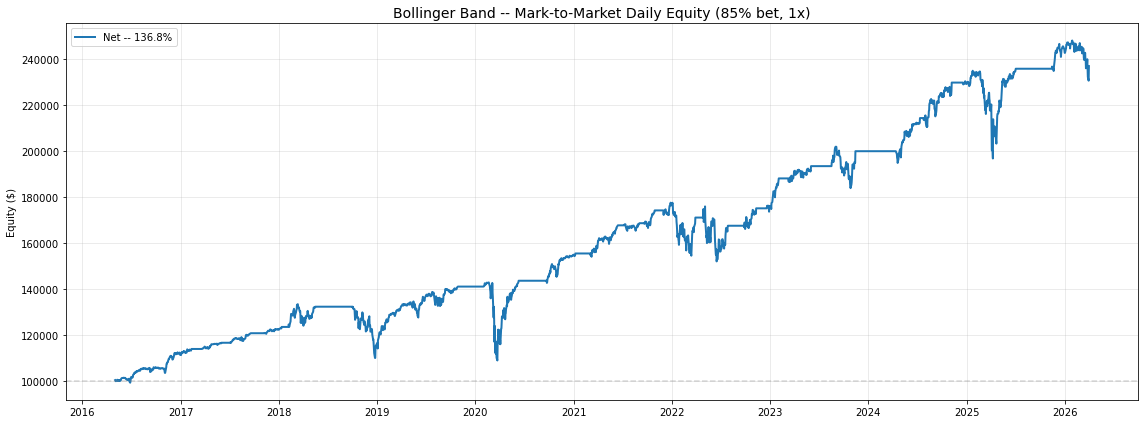

Final equity: $236,834
Total return: 136.8%
Max drawdown: -23.7%


In [23]:
# Plot mark-to-market daily equity
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily_eq.index.to_numpy(), daily_eq.values, linewidth=2, color="C0",
        label=f"Net -- {(daily_eq.iloc[-1]/STARTING_CAPITAL-1)*100:.1f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"Bollinger Band -- Mark-to-Market Daily Equity ({BET_SIZE:.0%} bet, {LEVERAGE}x)", fontsize=14)
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

print(f"Final equity: ${daily_eq.iloc[-1]:,.0f}")
print(f"Total return: {(daily_eq.iloc[-1]/STARTING_CAPITAL-1)*100:.1f}%")
peak = daily_eq.expanding().max()
max_dd = ((daily_eq - peak) / peak).min() * 100
print(f"Max drawdown: {max_dd:.1f}%")


## 7. Per-Instrument Breakdown & Exit Reason Analysis

In [24]:
for sym in SYMBOLS:
    subset = raw_trades[raw_trades["instrument"] == sym]
    if subset.empty:
        continue
    n = len(subset)
    wins = (subset["pct_return_gross"] > 0).sum()
    avg_ret = subset["pct_return_gross"].mean() * 100
    total_ret = ((1 + subset["pct_return_gross"]).prod() - 1) * 100
    avg_hold = (subset["exit_time"] - subset["entry_time"]).dt.days.mean()
    print(f"\n{sym}: {n} trades, WR={wins/n*100:.1f}%, Avg Return={avg_ret:+.3f}%, "
          f"Total={total_ret:+.1f}%, Avg Hold={avg_hold:.1f} days")

# Exit reason breakdown
print("\n" + "=" * 60)
print("EXIT REASON ANALYSIS")
print("=" * 60)
for reason in raw_trades["exit_reason"].unique():
    subset = raw_trades[raw_trades["exit_reason"] == reason]
    avg_ret = subset["pct_return_gross"].mean() * 100
    avg_hold = (subset["exit_time"] - subset["entry_time"]).dt.days.mean()
    wins = (subset["pct_return_gross"] > 0).sum()
    print(f"  {reason:<15} n={len(subset):3d}, WR={wins/len(subset)*100:.0f}%, "
          f"avg return: {avg_ret:+.2f}%, avg hold: {avg_hold:.0f}d")


SPY: 18 trades, WR=83.3%, Avg Return=+5.564%, Total=+158.3%, Avg Hold=82.3 days

QQQ: 18 trades, WR=77.8%, Avg Return=+7.133%, Total=+235.1%, Avg Hold=87.0 days

IWM: 21 trades, WR=66.7%, Avg Return=+4.362%, Total=+130.2%, Avg Hold=82.3 days

EXIT REASON ANALYSIS
  upper_band      n= 54, WR=80%, avg return: +6.06%, avg hold: 85d
  end_of_data     n=  3, WR=0%, avg return: -2.34%, avg hold: 69d


## 8. Overlap Analysis

Do SPY/QQQ/IWM fire independently, or are they the same signal?
If sleeves are highly correlated, consider simplifying to SPY-only.

ENTRY DATE OVERLAP (within ±3 business days)
  QQQ↔SPY: 7 overlapping entries (39% of QQQ's 18 trades, 39% of SPY's 18)
  IWM↔SPY: 7 overlapping entries (33% of IWM's 21 trades, 39% of SPY's 18)
  IWM↔QQQ: 5 overlapping entries (24% of IWM's 21 trades, 28% of QQQ's 18)

DAILY IN-POSITION CORRELATION (1 = always in position together)
      SPY   QQQ   IWM
SPY  1.00  0.47  0.36
QQQ  0.47  1.00  0.33
IWM  0.36  0.33  1.00

CONCURRENT POSITION STATS
  Days with ANY position:        1743 / 2587 (67.4%)
  Days with 2+ positions:        1165 / 2587 (45.0%)
  Days with all 3 positions:      558 / 2587 (21.6%)
  Share of active days that are all-3: 32.0%

RETURN CORRELATION (paired trades — entries within ±3 business days)
  QQQ↔SPY: n=7 paired trades, return correlation = -0.11
  IWM↔SPY: n=7 paired trades, return correlation = 0.68
  IWM↔QQQ: n=5 paired trades, return correlation = 0.63


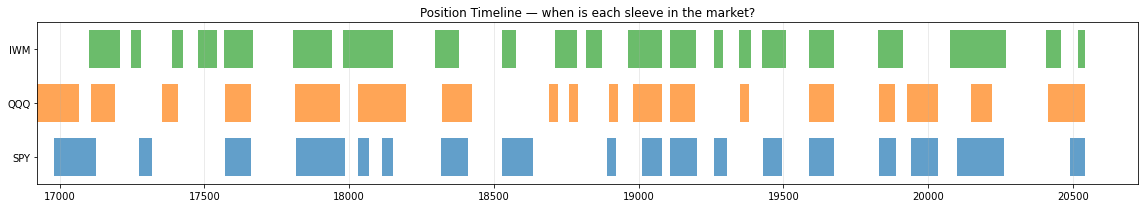


INTERPRETATION
  Avg pairwise in-position correlation = 0.39
  → Sleeves fire at genuinely different times. Multi-sleeve
    structure earns its keep — keep all three.


In [25]:
# Build a daily "in_position" series for each instrument
all_dates = pd.date_range(
    raw_trades["entry_time"].min(),
    raw_trades["exit_time"].max(),
    freq="B",
)
in_pos = pd.DataFrame(0, index=all_dates, columns=SYMBOLS)

for _, t in raw_trades.iterrows():
    sym = t["instrument"]
    mask = (in_pos.index >= t["entry_time"]) & (in_pos.index <= t["exit_time"])
    in_pos.loc[mask, sym] = 1

# ── 1. Entry date overlap ──
print("=" * 70)
print("ENTRY DATE OVERLAP (within ±3 business days)")
print("=" * 70)
entries_by_sym = {
    sym: raw_trades[raw_trades["instrument"] == sym]["entry_time"].dt.normalize()
    for sym in SYMBOLS
}

for a in SYMBOLS:
    for b in SYMBOLS:
        if a >= b:
            continue
        matches = 0
        for ea in entries_by_sym[a]:
            if ((entries_by_sym[b] - ea).abs() <= pd.Timedelta(days=3)).any():
                matches += 1
        n_a = len(entries_by_sym[a])
        n_b = len(entries_by_sym[b])
        pct_a = matches / n_a * 100 if n_a else 0
        pct_b = matches / n_b * 100 if n_b else 0
        print(f"  {a}↔{b}: {matches} overlapping entries "
              f"({pct_a:.0f}% of {a}'s {n_a} trades, {pct_b:.0f}% of {b}'s {n_b})")

# ── 2. Daily in-position correlation ──
print("\n" + "=" * 70)
print("DAILY IN-POSITION CORRELATION (1 = always in position together)")
print("=" * 70)
corr_matrix = in_pos.corr()
print(corr_matrix.round(2).to_string())

# ── 3. Fraction of days with concurrent positions ──
print("\n" + "=" * 70)
print("CONCURRENT POSITION STATS")
print("=" * 70)
total_days = len(in_pos)
any_pos_days = (in_pos.sum(axis=1) > 0).sum()
all_three_days = (in_pos.sum(axis=1) == 3).sum()
two_plus_days = (in_pos.sum(axis=1) >= 2).sum()
print(f"  Days with ANY position:       {any_pos_days:5d} / {total_days} ({any_pos_days/total_days*100:.1f}%)")
print(f"  Days with 2+ positions:       {two_plus_days:5d} / {total_days} ({two_plus_days/total_days*100:.1f}%)")
print(f"  Days with all 3 positions:    {all_three_days:5d} / {total_days} ({all_three_days/total_days*100:.1f}%)")
print(f"  Share of active days that are all-3: "
      f"{all_three_days/any_pos_days*100:.1f}%" if any_pos_days else "  n/a")

# ── 4. Return correlation across paired trades ──
print("\n" + "=" * 70)
print("RETURN CORRELATION (paired trades — entries within ±3 business days)")
print("=" * 70)
for a in SYMBOLS:
    for b in SYMBOLS:
        if a >= b:
            continue
        pairs_a, pairs_b = [], []
        ta = raw_trades[raw_trades["instrument"] == a].reset_index(drop=True)
        tb = raw_trades[raw_trades["instrument"] == b].reset_index(drop=True)
        for _, row_a in ta.iterrows():
            diffs = (tb["entry_time"] - row_a["entry_time"]).abs()
            if (diffs <= pd.Timedelta(days=3)).any():
                idx = diffs.idxmin()
                pairs_a.append(row_a["pct_return_gross"])
                pairs_b.append(tb.loc[idx, "pct_return_gross"])
        if len(pairs_a) >= 5:
            c = np.corrcoef(pairs_a, pairs_b)[0, 1]
            print(f"  {a}↔{b}: n={len(pairs_a)} paired trades, "
                  f"return correlation = {c:.2f}")
        else:
            print(f"  {a}↔{b}: n={len(pairs_a)} paired trades (too few for correlation)")

# ── 5. Visual — gantt-style timeline of positions ──
fig, ax = plt.subplots(figsize=(16, 3))
for i, sym in enumerate(SYMBOLS):
    sym_trades = raw_trades[raw_trades["instrument"] == sym]
    for _, t in sym_trades.iterrows():
        ax.barh(i, (t["exit_time"] - t["entry_time"]).days,
                left=t["entry_time"], height=0.7, color=f"C{i}", alpha=0.7)
ax.set_yticks(range(len(SYMBOLS)))
ax.set_yticklabels(SYMBOLS)
ax.set_title("Position Timeline — when is each sleeve in the market?")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

# ── 6. Verdict ──
print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
avg_corr = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean()
if avg_corr > 0.7:
    print(f"  Avg pairwise in-position correlation = {avg_corr:.2f}")
    print("  → Sleeves fire together most of the time. SPY-only is likely")
    print("    ~equivalent and much simpler. Consider dropping QQQ/IWM.")
elif avg_corr > 0.4:
    print(f"  Avg pairwise in-position correlation = {avg_corr:.2f}")
    print("  → Moderate overlap. Multi-sleeve adds some diversification")
    print("    but check whether the extra complexity pays off in Sharpe.")
else:
    print(f"  Avg pairwise in-position correlation = {avg_corr:.2f}")
    print("  → Sleeves fire at genuinely different times. Multi-sleeve")
    print("    structure earns its keep — keep all three.")

## 9. Save Standardized Trades

Saves raw signal trades for PM consumption. No sizing, no fees baked in.
Run `Bollinger_Band_Implementation.ipynb` to compare sizing methods.

In [26]:
import os, json

os.makedirs("results", exist_ok=True)

# Standard trades CSV
std_cols = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
raw_trades[std_cols].to_csv(f"results/{SAVE_NAME}_trades.csv", index=False)
print(f"Saved {len(raw_trades)} standardized trades → results/{SAVE_NAME}_trades.csv")

# Summary JSON
summary = {
    "strategy":    STRATEGY_NAME,
    "instruments": SYMBOLS,
    "portfolio":   "long_term",
    "period":      f"{START_DATE} → {END_DATE}",
    "params":      DEFAULT_PARAMS,
    "trades":      len(raw_trades),
    "significance": {
        "gross": {"sharpe": report_gross["bootstrap"]["observed_sharpe"],
                  "verdict": report_gross["verdict"],
                  "tests_passed": report_gross["tests_passed"]},
        "net":   {"sharpe": report_net["bootstrap"]["observed_sharpe"],
                  "verdict": report_net["verdict"],
                  "tests_passed": report_net["tests_passed"]},
    },
}
with open(f"results/{SAVE_NAME}_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved summary → results/{SAVE_NAME}_summary.json")

print(f"\nNext: run Bollinger_Band_Implementation.ipynb for sizing comparison")

Saved 57 standardized trades → results/bollinger_band_trades.csv
Saved summary → results/bollinger_band_summary.json

Next: run Bollinger_Band_Implementation.ipynb for sizing comparison
